# F1 예선 랩타임 예측 프로젝트

## 데이터로 본 '가장 빠른 한 바퀴'

---

### 오늘 풀 문제
> **어떤 드라이버가, 어떤 팀 소속으로, 어떤 서킷에서 예선을 볼 때, 몇 초의 랩타임을 낼 것인가?**

이 값은 연속된 실수(초)이므로 **회귀(Regression)** 문제이다.

---

### 왜 이 문제가 재미있나?
- F1은 **드라이버 실력 + 팀(차량) 성능 + 서킷 특성 + 날씨**가 복합적으로 작용
- 데이터가 **73년치(1950~2024)** 쌓여 있어 ML에 풍부한 신호가 있음
- 결과 해석이 직관적 — '해밀턴이 스파에서 1:42를 뽑는다'처럼 사람이 검증 가능

## 1. F1 기초 상식 (30초 요약)

### F1이 뭔가요?
- **포뮬러 원(Formula 1)**: 세계 최고 수준의 자동차 경주 대회
- 매년 3월~12월에 전 세계 24개 서킷(경기장)을 돌며 **그랑프리(GP)** 개최
- 한 그랑프리는 보통 **금(연습)-토(예선)-일(본선)** 3일간 진행

### 예선(Qualifying)?
본선 경기에서 **출발 순서(그리드)를 결정**하는 예선전. 3단계로 진행된다.

| 세션 | 시간 | 참가 차량 | 탈락 | 역할 |
|---|---|---|---|---|
| **Q1** | 18분 | 20대 전원 | 하위 5대 | 1차 컷 |
| **Q2** | 15분 | 15대 | 하위 5대 | 2차 컷 |
| **Q3** | 12분 | **상위 10대** | — | **폴포지션 결정** |

### 이 프로젝트의 타겟: `q3` (Q3 최고 랩타임)
- 상위 10명만 도전하는 **"최고 속도의 순수 승부"**
- 연료는 최소량, 타이어는 가장 빠른 소프트 컴파운드 → **차량과 드라이버의 한계 성능**이 드러나는 순간
- 변수가 Q1/Q2보다 적어 예측 모델을 만들기에 가장 깔끔함

## 2. 데이터 소개

### 출처
Kaggle **"Formula 1 World Championship (1950 - 2020+)"** — 1950년부터 모든 공식 기록

### 구조: 13개 CSV의 관계형 데이터베이스

```
[races] --- 경기 정보 (언제, 어디서)
   │
   ├── [qualifying]    예선 기록 ← 우리의 타겟이 여기
   ├── [results]       본선 결과
   ├── [lap_times]     랩 단위 기록 (백만 행)
   └── [pit_stops]     피트스톱 정보

[drivers]        드라이버 마스터 (이름, 국적, 생년)
[constructors]   팀 마스터 (메르세데스, 페라리 등)
[circuits]       서킷 마스터 (위도/경도/고도)
```

### 이번 분석에 사용할 6개
- `qualifying` — **타겟 데이터**
- `races` — 언제·어디서 열린 경기인지
- `drivers` — 누가 운전했는지
- `constructors` — 어느 팀인지
- `circuits` — 어떤 서킷인지
- (보조) `results` — 본선 성적을 피처로 쓸 수도 있음

## 3. 데이터 로딩

`datasets/f1/` 폴더에 CSV 6개를 한 번에 불러온다. 각 파일의 크기를 `shape`로 확인해서 로딩이 제대로 됐는지 점검.

In [1]:
# 처음 한 번만 실행
# %pip install xgboost lightgbm meteostat
# %pip install --user meteostat

In [2]:
import pandas as pd
import numpy as np

DATA_DIR = './datasets/f1/'

races        = pd.read_csv(DATA_DIR + 'races.csv')
results      = pd.read_csv(DATA_DIR + 'results.csv')
qualifying   = pd.read_csv(DATA_DIR + 'qualifying.csv')
drivers      = pd.read_csv(DATA_DIR + 'drivers.csv')
constructors = pd.read_csv(DATA_DIR + 'constructors.csv')
circuits     = pd.read_csv(DATA_DIR + 'circuits.csv')

print('races:       ', races.shape, '— 전체 그랑프리 목록')
print('results:     ', results.shape, '— 본선 결과')
print('qualifying:  ', qualifying.shape, '— 예선 기록 (타겟)')
print('drivers:     ', drivers.shape, '— 드라이버')
print('constructors:', constructors.shape, '— 팀')
print('circuits:    ', circuits.shape, '— 서킷')

races:        (1171, 18) — 전체 그랑프리 목록
results:      (27304, 18) — 본선 결과
qualifying:   (11036, 9) — 예선 기록 (타겟)
drivers:      (865, 9) — 드라이버
constructors: (214, 5) — 팀
circuits:     (78, 9) — 서킷


In [3]:
# 핵심 테이블 미리보기
qualifying.head()

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


### `qualifying` 테이블 컬럼 해설

| 컬럼 | 의미 |
|---|---|
| `qualifyId` | 예선 기록 고유 번호 |
| `raceId` | 어느 경기인지 (→ `races`와 연결) |
| `driverId` | 누가 운전했는지 (→ `drivers`와 연결) |
| `constructorId` | 어느 팀인지 (→ `constructors`와 연결) |
| `number` | 드라이버 번호 (#44 = 해밀턴 등) |
| `position` | 예선 최종 순위 (1등 = 폴포지션) |
| `q1`, `q2`, `q3` | **각 세션 최고 랩타임** (`'1:20.835'` 문자열) |

**주의**: `q1`/`q2`/`q3`은 **문자열**이라 숫자 계산을 위해 초 단위로 변환해야 함 → 곧 처리

## 4. 마스터 테이블 생성 (merge)

### 왜 합쳐야 하나?
현재 데이터는 정규화되어 있음. 예선 테이블엔 `driverId=1`만 있지 이름은 없음. 모델에 넣고 해석하려면 **하나의 큰 테이블**로 합쳐야 함.

### JOIN 전략
```
qualifying
   + races (raceId)         → 시즌, 라운드, 날짜, 서킷 정보 추가
   + drivers (driverId)     → 드라이버 이름, 국적
   + constructors (constrId)→ 팀 이름, 팀 국적
   + circuits (circuitId)   → 서킷 국가, 고도
```
모두 **left join** — 예선 기록을 기준으로 정보를 덧붙이는 방식.

In [4]:
df = qualifying.merge(
    races[['raceId', 'year', 'round', 'circuitId', 'name', 'date']].rename(columns={'name': 'race_name'}),
    on='raceId', how='left'
).merge(
    drivers[['driverId', 'driverRef', 'nationality']].rename(columns={'nationality': 'driver_nationality'}),
    on='driverId', how='left'
).merge(
    constructors[['constructorId', 'constructorRef', 'nationality']].rename(columns={'nationality': 'team_nationality'}),
    on='constructorId', how='left'
).merge(
    circuits[['circuitId', 'circuitRef', 'country', 'alt']].rename(columns={'country': 'circuit_country', 'alt': 'circuit_altitude'}),
    on='circuitId', how='left'
)

print('합쳐진 마스터 테이블:', df.shape)
df[['year', 'race_name', 'driverRef', 'constructorRef', 'position', 'q1', 'q2', 'q3']].tail(10)

합쳐진 마스터 테이블: (11036, 21)


,year,race_name,driverRef,constructorRef,position,q1,q2,q3
11026,2026,Japanese Grand Prix,hulkenberg,audi,13,1:30.358,1:30.387,\N
11027,2026,Japanese Grand Prix,lawson,rb,14,1:30.657,1:30.495,\N
11028,2026,Japanese Grand Prix,colapinto,alpine,15,1:30.931,1:30.627,\N
11029,2026,Japanese Grand Prix,sainz,williams,16,1:30.927,1:31.033,\N
11030,2026,Japanese Grand Prix,albon,williams,17,1:31.088,\N,\N
11031,2026,Japanese Grand Prix,bearman,haas,18,1:31.090,\N,\N
11032,2026,Japanese Grand Prix,perez,cadillac,19,1:32.206,\N,\N
11033,2026,Japanese Grand Prix,bottas,cadillac,20,1:32.330,\N,\N
11034,2026,Japanese Grand Prix,alonso,aston_martin,21,1:32.646,\N,\N
11035,2026,Japanese Grand Prix,stroll,aston_martin,22,1:32.920,\N,\N


### 한국어 이름 매핑 (발표용)

드라이버·팀·서킷 이름을 한국어로 번역. **분석 내부 로직은 영문 키를 그대로 쓰고**, 표와 차트의 라벨만 한국어로 바꿀 용도.

In [5]:
# 드라이버 매핑
driver_ko = {
    # 2014~현재 (하이브리드 시대)
    'hamilton': '해밀턴', 'max_verstappen': '베르스타펜', 'leclerc': '르클레르',
    'sainz': '사인츠', 'russell': '러셀', 'norris': '노리스',
    'perez': '페레스', 'bottas': '보타스', 'ricciardo': '리카르도',
    'alonso': '알론소', 'gasly': '가슬리', 'ocon': '오콘',
    'stroll': '스트롤', 'vettel': '베텔', 'rosberg': '로즈버그',
    'raikkonen': '라이코넨', 'kvyat': '크비얏', 'hulkenberg': '휠켄베르크',
    'massa': '마싸', 'grosjean': '그로장', 'button': '버튼',
    'kevin_magnussen': '마그누센', 'tsunoda': '츠노다', 'albon': '알본',
    'piastri': '피아스트리', 'zhou': '저우', 'sargeant': '사전트',
    'bearman': '베어만', 'lawson': '로슨', 'de_vries': '더 프리스',
    'mick_schumacher': '믹 슈마허', 'latifi': '라티피', 'nasr': '나세르',
    'ericsson': '에릭손', 'brendon_hartley': '하틀리',
    'kubica': '쿠비차', 'wehrlein': '베를라인', 'jolyon_palmer': '파머',
    'giovinazzi': '조비나치', 'vandoorne': '반도른',
    'colapinto': '콜라핀토', 'doohan': '두한',
    'vergne': '베르뉴', 'jules_bianchi': '쥘 비앙키', 'lotterer': '로테러',
    'haryanto': '하리얀토', 'resta': '디 레스타', 'sirotkin': '시로트킨',
    'aitken': '에이트킨', 'pietro_fittipaldi': '피에트로 피티팔디',
    'mazepin': '마제핀', 'hadjar': '아자르', 'bortoleto': '보르톨레토',
    'antonelli': '안토넬리', 'arvid_lindblad': '린드블라드', 'sato' : '사토',
    # 2000~2013 (V8/V10 시대)
    'kovalainen': '코발라이넨', 'heidfeld': '하이드펠트',
    'trulli': '트룰리', 'coulthard': '쿨사드', 'glock': '글록',
    'barrichello': '바리첼로', 'nakajima': '나카지마', 'webber': '웨버',
    'michael_schumacher': '미하엘 슈마허', 'kobayashi': '코바야시',
    'petrov': '페트로프', 'senna': '세나',
    'alguersuari': '알게르수아리', 'buemi': '부에미', 'sutil': '주틸',
    'fisichella': '피지켈라', 'liuzzi': '리우치', 'klien': '클리엔',
    'bourdais': '부르데', 'piquet_jr': '피케 주니어',
    'karthikeyan': '카르티케얀', 'maldonado': '말도나도',
    'd_ambrosio': '담브로시오', 'di_resta': '디 레스타',
    'gutierrez': '구티에레스', 'bianchi': '비앙키', 'chilton': '칠튼',
    'chandhok': '찬독', 'montagny': '몽타니',
    'ralf_schumacher': '랄프 슈마허', 'montoya': '몽토야',
    'villeneuve': '빌뇌브', 'panis': '파니스', 'frentzen': '프렌첸',
    'irvine': '어바인', 'hakkinen': '하키넨', 'wurz': '부르츠',
    'zanardi': '잔나르디', 'herbert': '허버트', 'diniz': '디니스',
    'berger': '베르거',
    'fittipaldi': '에머슨 피티팔디', 'hill': '힐',
    'albers': '알버스', 'doornbos': '도른보스', 'speed': '스피드',
    'merhi': '메르히', 'rossi': '로시', 'stevens': '스티븐스',
}

# 팀 (컨스트럭터)
team_ko = {
    # 2014~현재
    'mercedes': '메르세데스', 'red_bull': '레드불', 'ferrari': '페라리',
    'mclaren': '맥라렌', 'williams': '윌리엄스', 'renault': '르노',
    'force_india': '포스인디아', 'sauber': '자우버', 'alpine': '알핀',
    'alphatauri': '알파타우리', 'aston_martin': '애스턴마틴',
    'racing_point': '레이싱포인트', 'haas': '하스', 'toro_rosso': '토로로소',
    'lotus_f1': '로터스', 'manor': '매너', 'marussia': '마루시아',
    'caterham': '캐터햄', 'rb': '레이싱불',
    'alfa': '알파 로메오', 'audi': '아우디', 'cadillac': '캐딜락',
    # 2000~2013
    'bmw_sauber': 'BMW 자우버', 'toyota': '토요타', 'honda': '혼다',
    'brawn': '브론GP', 'virgin': '버진', 'hrt': 'HRT',
    'super_aguri': '슈퍼 아구리', 'bar': 'BAR', 'jaguar': '재규어',
    'minardi': '미나르디', 'jordan': '조던', 'spyker': '스파이커',
    'midland': '미드랜드', 'arrows': '애로우즈', 'prost': '프로스트',
    'stewart': '스튜어트', 'benetton': '베네통', 'tyrrell': '티렐',
    'jaguar_racing': '재규어 레이싱', 'lotus_racing': '로터스 레이싱',
}

# 서킷
circuit_ko = {
    'monaco': '모나코', 'silverstone': '실버스톤', 'spa': '스파',
    'monza': '몬자', 'suzuka': '스즈카', 'interlagos': '인터라고스',
    'bahrain': '바레인', 'catalunya': '카탈루냐', 'americas': '오스틴',
    'yas_marina': '야스마리나', 'albert_park': '알버트파크',
    'hungaroring': '헝가로링', 'istanbul': '이스탄불',
    'red_bull_ring': '레드불링', 'nurburgring': '뉘르부르크링',
    'shanghai': '상하이', 'baku': '바쿠', 'sochi': '소치',
    'marina_bay': '마리나베이', 'hockenheim': '호켄하임',
    'losail': '로사일', 'portimao': '포르티망', 'jeddah': '제다',
    'miami': '마이애미', 'zandvoort': '잔트포르트', 'ricard': '폴리카르',
    'mugello': '무젤로', 'vegas': '라스베이거스', 'imola': '이몰라',
    'villeneuve': '몬트리올', 'indianapolis': '인디애나폴리스',
    'fuji': '후지', 'korea': '영암', 'buddh': '부다 인터내셔널',
    'sepang': '세팡', 'valencia': '발렌시아', 'estoril': '이스토릴',
    'jerez': '헤레스', 'magny_cours': '마니쿠르',
    'osterreichring': '외스터라이히링', 'donington': '도닝턴',
    'adelaide': '애들레이드', "hockenheimring" : '호켄하임링'
}

# 매핑 적용
df['driver_ko']  = df['driverRef'].map(driver_ko).fillna(df['driverRef'])
df['team_ko']    = df['constructorRef'].map(team_ko).fillna(df['constructorRef'])
df['circuit_ko'] = df['circuitRef'].map(circuit_ko).fillna(df['circuitRef'])

# 매핑 확인
check_df = df[df['year'] >= 2014][['driverRef', 'driver_ko', 'constructorRef', 'team_ko']].drop_duplicates()
not_mapped_drivers = check_df[check_df['driverRef'] == check_df['driver_ko']]['driverRef'].unique()
not_mapped_teams   = check_df[check_df['constructorRef'] == check_df['team_ko']]['constructorRef'].unique()
df[['driverRef', 'driver_ko', 'constructorRef', 'team_ko', 'circuitRef', 'circuit_ko']].drop_duplicates().head(30)

,driverRef,driver_ko,constructorRef,team_ko,circuitRef,circuit_ko
0,hamilton,해밀턴,mclaren,맥라렌,albert_park,알버트파크
1,kubica,쿠비차,bmw_sauber,BMW 자우버,albert_park,알버트파크
2,kovalainen,코발라이넨,mclaren,맥라렌,albert_park,알버트파크
3,massa,마싸,ferrari,페라리,albert_park,알버트파크
4,heidfeld,하이드펠트,bmw_sauber,BMW 자우버,albert_park,알버트파크
5,trulli,트룰리,toyota,토요타,albert_park,알버트파크
6,rosberg,로즈버그,williams,윌리엄스,albert_park,알버트파크
7,coulthard,쿨사드,red_bull,레드불,albert_park,알버트파크
8,glock,글록,toyota,토요타,albert_park,알버트파크
9,vettel,베텔,toro_rosso,토로로소,albert_park,알버트파크


## 5. 타겟 변환: 문자열 → 숫자

### 문제
랩타임이 `'1:20.835'` 같은 문자열. 숫자가 아니면 모델이 학습 불가.

### 해결
`M:SS.mmm` 포맷을 **초 단위 float**로 변환:
- `'1:20.835'` → `1*60 + 20.835` = `80.835초`

### 엣지 케이스
- 결측치(`NaN`), Kaggle의 `'\N'` 표기, 빈 문자열 → `NaN`으로 처리

In [6]:
def laptime_to_seconds(s):
    """랩타임 문자열 'M:SS.mmm' → 초 단위 float."""
    if pd.isna(s) or s == '\\N' or s == '':
        return np.nan
    try:
        m, rest = s.split(':')
        return int(m) * 60 + float(rest)
    except (ValueError, AttributeError):
        return np.nan

for col in ['q1', 'q2', 'q3']:
    df[col + '_sec'] = df[col].apply(laptime_to_seconds)

# 변환 결과 확인
df[['q1', 'q1_sec', 'q2', 'q2_sec', 'q3', 'q3_sec']].head(10)

,q1,q1_sec,q2,q2_sec,q3,q3_sec
0,1:26.572,86.572,1:25.187,85.187,1:26.714,86.714
1,1:26.103,86.103,1:25.315,85.315,1:26.869,86.869
2,1:25.664,85.664,1:25.452,85.452,1:27.079,87.079
3,1:25.994,85.994,1:25.691,85.691,1:27.178,87.178
4,1:25.960,85.960,1:25.518,85.518,1:27.236,87.236
5,1:26.427,86.427,1:26.101,86.101,1:28.527,88.527
6,1:26.295,86.295,1:26.059,86.059,1:28.687,88.687
7,1:26.381,86.381,1:26.063,86.063,1:29.041,89.041
8,1:26.919,86.919,1:26.164,86.164,1:29.593,89.593
9,1:26.702,86.702,1:25.842,85.842,\N,NaN


## 6. 데이터 필터링: 왜 2014년 이후만?

### F1의 "기술 혁명"들
F1은 규정이 10년 단위로 크게 바뀝니다. 차량 성능이 그때마다 급변하기 때문에 **옛날과 최근을 한 모델에 섞으면 망함**.

| 시대 | 특징 | 대략적인 차량 성능 |
|---|---|---|
| 1950~1980 | 자연흡기 V8/V12 | 느림 |
| 1980~1988 | 터보 1세대 | 매우 빠름 |
| 1989~2005 | V10 자연흡기 | 중간 |
| 2006~2013 | V8 자연흡기 | 느려짐 |
| **2014~현재** | **터보 하이브리드 V6** | **현 체제** |

### 선택: 2014년 이후 (하이브리드 시대)
- 규정이 한 체제 내에서 안정적
- 약 10년치 데이터 → 충분한 학습 데이터량
- 현재 팬들에게 친숙한 선수들 (해밀턴, 베르스타펜, 르클레르)

### 추가 필터: Q3 진출자만
타겟이 `q3_sec`이므로, Q3까지 못 올라온 선수(하위 10명)는 자동 제외.

In [7]:
pre_df = df.dropna(subset=['q3_sec']).copy()
# 2014~2024만 (2025/2026은 미래 placeholder 제외)
pre_df = pre_df[(pre_df['year'] >= 2014) & (pre_df['year'] <= 2024)].reset_index(drop=True)

print('필터 후 샘플 수:', pre_df.shape[0])
print('시즌 범위:      ', pre_df['year'].min(), '~', pre_df['year'].max())
print('총 레이스 수:   ', pre_df['raceId'].nunique(), '경기')
print('고유 드라이버:  ', pre_df['driverRef'].nunique(), '명')
print('고유 팀:        ', pre_df['constructorRef'].nunique(), '팀')
print('고유 서킷:      ', pre_df['circuitRef'].nunique(), '개')

필터 후 샘플 수: 2213
시즌 범위:       2014 ~ 2024
총 레이스 수:    227 경기
고유 드라이버:   41 명
고유 팀:         17 팀
고유 서킷:       32 개


## 7. 탐색적 분석 (EDA)

데이터를 눈으로 보고 **'어떤 피처가 중요할지'** 감을 잡는 단계.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### 7-1. 시즌별 랩타임 추이

**관찰 포인트**
- 기술 발전으로 매년 조금씩 빨라지는가?
- 규정 변경이 있던 해(2017, 2022)엔 점프가 있는가?

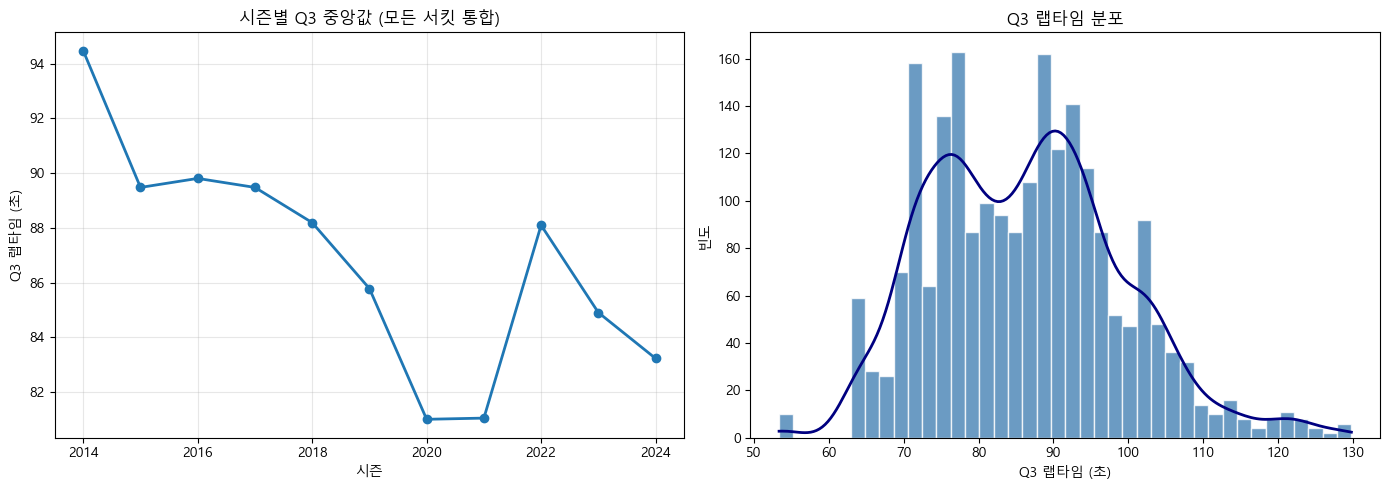

In [9]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

pre_df.groupby('year')['q3_sec'].median().plot(ax=ax[0], marker='o', linewidth=2)
ax[0].set_title('시즌별 Q3 중앙값 (모든 서킷 통합)')
ax[0].set_ylabel('Q3 랩타임 (초)')
ax[0].set_xlabel('시즌')
ax[0].grid(alpha=0.3)

vals = pre_df['q3_sec'].dropna()
counts, bins, _ = ax[1].hist(vals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
# KDE 곡선 수동으로 얹기
kde = gaussian_kde(vals)
xs = np.linspace(vals.min(), vals.max(), 200)
ax[1].plot(xs, kde(xs) * len(vals) * (bins[1]-bins[0]), color='navy', linewidth=2)
ax[1].set_title('Q3 랩타임 분포')
ax[1].set_xlabel('Q3 랩타임 (초)')
ax[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

### 7-2. 팀별 평균 성능

**관찰 포인트**
- 상위권은 메르세데스·레드불·페라리 순일 것 (2014~2024 도미넌트)
- 팀 간 격차가 얼마나 큰가 — **팀이 강력한 예측 변수가 될지 결정**

In [10]:
team_perf = (pre_df.groupby('team_ko')['q3_sec']
             .agg(['mean', 'count'])
             .query('count >= 20')
             .sort_values('mean'))
print('팀별 Q3 평균 랩타임 (최소 20회 Q3 진출팀만)')
team_perf.round(3)

팀별 Q3 평균 랩타임 (최소 20회 Q3 진출팀만)


,mean,count
team_ko,,
레이싱포인트,83.344,28
하스,84.052,85
알파타우리,84.390,58
알핀,84.461,79
애스턴마틴,84.790,69
알파 로메오,85.222,32
맥라렌,85.629,239
메르세데스,85.751,423
페라리,85.940,384


### 7-3. 서킷별 난이도

**관찰 포인트**
- 서킷 길이가 다르므로 절대 랩타임 차이 큼
- 모나코(짧고 느림) vs 스파(길고 빠름) 대비가 드라마틱
- **서킷이 강력한 예측 변수**가 될 것

In [11]:
circuit_perf = (pre_df.groupby('circuit_ko')['q3_sec']
                .agg(['mean', 'min', 'count'])
                .query('count >= 5')
                .sort_values('mean'))
print('서킷별 Q3 랩타임 (최소 5회 개최 서킷만)')
circuit_perf.round(3)

서킷별 Q3 랩타임 (최소 5회 개최 서킷만)


,mean,min,count
circuit_ko,,,
레드불링,66.922,62.939,125
잔트포르트,70.759,68.885,38
인터라고스,71.588,67.281,97
모나코,72.879,70.166,99
호켄하임링,74.350,71.212,39
몬트리올,75.807,70.240,88
무젤로,76.129,75.144,9
rodriguez,77.670,74.758,90
포르티망,78.152,76.652,19


### 7-4. 상관관계 히트맵

수치 피처들끼리의 상관계수를 한눈에 확인. 타겟(`q3_sec`)과 가장 상관 높은 피처가 예측에 유효할 가능성.

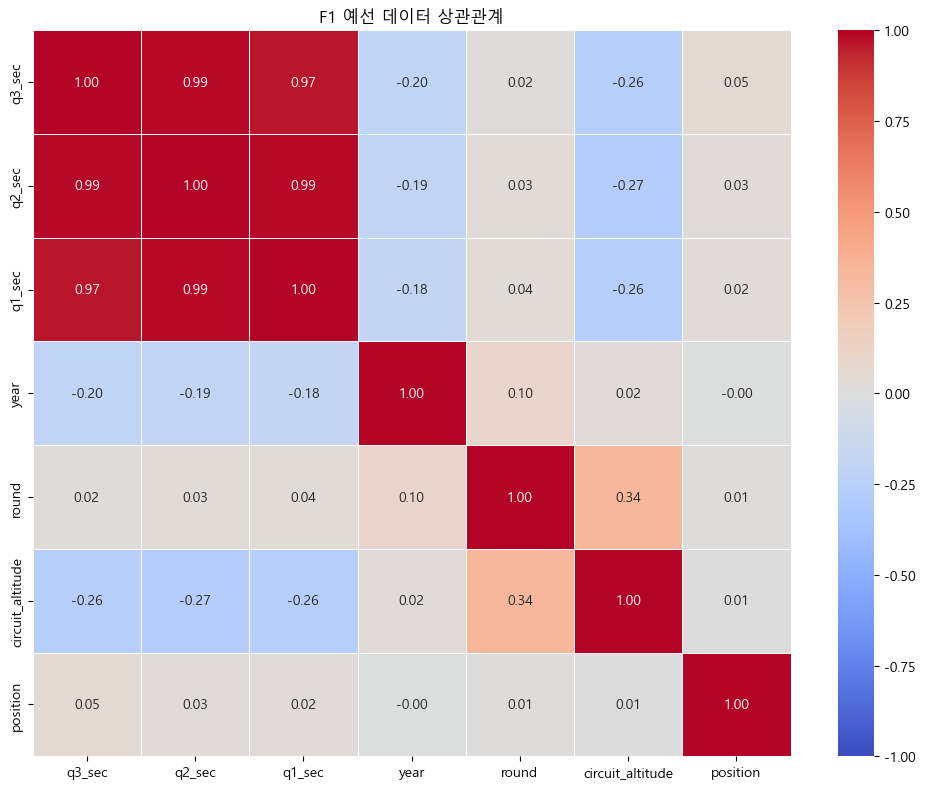

In [12]:
numeric_cols = ['q3_sec', 'q2_sec', 'q1_sec', 'year', 'round', 'circuit_altitude', 'position']
corr = pre_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0, vmin=-1, vmax=1)
plt.title('F1 예선 데이터 상관관계')
plt.tight_layout()
plt.show()

### 7-5. 피처 분포 히스토그램 그리드

모든 수치 피처의 분포를 한 번에 확인. 왜도(skewness), 이상치, 이봉분포 등을 눈으로 잡아냄.

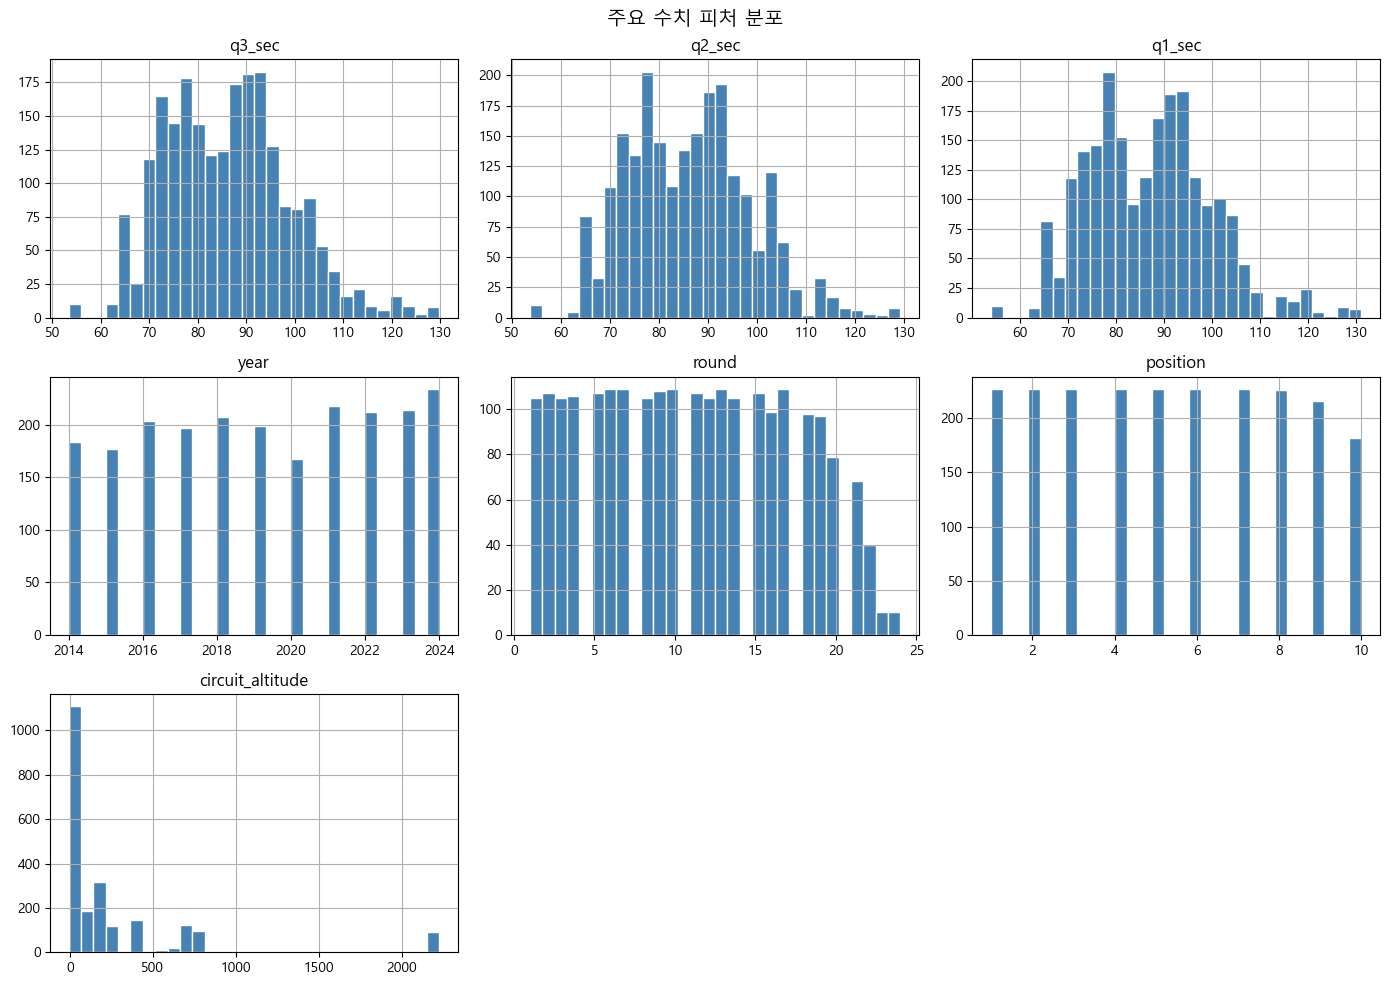

In [13]:
pre_df[['q3_sec', 'q2_sec', 'q1_sec', 'year', 'round',
        'position', 'circuit_altitude']].hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('주요 수치 피처 분포', fontsize=14)
plt.tight_layout()
plt.show()

### 7-6. 외부 API로 날씨 데이터 보강 (시간별)

### 첫 시도는 실패했던 이유
처음엔 **일간 평균** 데이터를 썼는데 R²가 0.78 → 0.61로 오히려 악화됐어요.
- **강수 확보율 60%** — 40%가 median(0)으로 채워져 실제 우천 → 건조 오라벨링
- **일간 평균의 한계** — 오후 1시간짜리 예선을 하루 평균이 대표할 수 없음
- **1mm 임계값** — 이슬비·새벽 비까지 우천으로 잡아 정밀도 낮음

### 이번엔 시간별 데이터로 재시도
- `meteostat.Hourly`로 **경기일 24시간 × 1시간 단위** 조회
- **시간당 최대 강수량**으로 우천 여부 판단 (하루 중 비 온 시간대만 잡힘)
- 10배 더 정밀한 신호 기대

### 새로 만들 피처
| 피처 | 계산 | 의미 |
|---|---|---|
| `temp_h` | 24시간 평균 기온 | 그날 전반적 기온 |
| `prcp_max_h` | **시간당 최대 강수** | ⭐ 최강 신호 |
| `prcp_sum_h` | 하루 총 강수 | 전체 누적 |
| `wspd_h` | 24시간 평균 풍속 | 바람 |
| `was_wet_h` | `prcp_max_h > 0.5` | 시간당 0.5mm 넘는 비가 한 번이라도 있었나 |

In [14]:
import os
import warnings
import logging
from meteostat import Point, Hourly

warnings.filterwarnings('ignore')
logging.getLogger('meteostat').setLevel(logging.ERROR)

weather_cache = './datasets/f1/weather_hourly.csv'

if os.path.exists(weather_cache):
    weather_df = pd.read_csv(weather_cache)
    print(f'캐시된 시간별 날씨 데이터 로드: {weather_df.shape}')
else:
    print('시간별 날씨 데이터 다운로드 중... (경기 1건당 24시간 조회, 10~15분 소요)')
    print('(관측소 접근 실패 경고는 무시해도 됩니다)')

    target_races = (pre_df[['raceId', 'circuitId', 'date']]
                    .drop_duplicates('raceId')
                    .merge(circuits[['circuitId', 'lat', 'lng']], on='circuitId'))

    records = []
    for idx, row in target_races.iterrows():
        dt = pd.to_datetime(row['date'])
        start = dt.replace(hour=0, minute=0, second=0)
        end   = dt.replace(hour=23, minute=59, second=59)
        loc   = Point(row['lat'], row['lng'])
        try:
            data = Hourly(loc, start, end).fetch()
            if data.empty:
                records.append({'raceId': row['raceId'],
                                'temp_h': np.nan, 'prcp_max_h': np.nan,
                                'prcp_sum_h': np.nan, 'wspd_h': np.nan})
            else:
                records.append({
                    'raceId': row['raceId'],
                    'temp_h':     data['temp'].mean() if 'temp' in data.columns else np.nan,
                    'prcp_max_h': data['prcp'].max()  if 'prcp' in data.columns else np.nan,
                    'prcp_sum_h': data['prcp'].sum()  if 'prcp' in data.columns else np.nan,
                    'wspd_h':     data['wspd'].mean() if 'wspd' in data.columns else np.nan,
                })
        except Exception as e:
            records.append({'raceId': row['raceId'],
                            'temp_h': np.nan, 'prcp_max_h': np.nan,
                            'prcp_sum_h': np.nan, 'wspd_h': np.nan})
        if (idx + 1) % 30 == 0:
            print(f'  진행: {idx+1}/{len(target_races)}')

    weather_df = pd.DataFrame(records)
    weather_df.to_csv(weather_cache, index=False)
    print(f'저장됨: {weather_cache} ({weather_df.shape})')

# 이전 daily weather 컬럼이 남아있으면 제거 (재실행 안전성)
for col in ['tavg', 'prcp', 'wspd', 'was_wet']:
    if col in pre_df.columns:
        pre_df = pre_df.drop(columns=col)

# merge
pre_df = pre_df.merge(weather_df, on='raceId', how='left')

# 파생 피처: 시간당 0.5mm 초과 → 우천
pre_df['was_wet_h'] = (pre_df['prcp_max_h'].fillna(0) > 0.5).astype(int)

# 결측치 대치
for col in ['temp_h', 'prcp_max_h', 'prcp_sum_h', 'wspd_h']:
    pre_df[col] = pre_df[col].fillna(pre_df[col].median())

print(f'\nshape: {pre_df.shape}')
print(f'우천 예선 비율 (시간별 기준): {pre_df["was_wet_h"].mean():.3f}')
print(f'날씨 데이터 확보율:')
print(f'  temp_h:     {(1 - weather_df["temp_h"].isna().mean()):.1%}')
print(f'  prcp_max_h: {(1 - weather_df["prcp_max_h"].isna().mean()):.1%}')
print(f'  wspd_h:     {(1 - weather_df["wspd_h"].isna().mean()):.1%}')
print()
pre_df[['year', 'race_name', 'temp_h', 'prcp_max_h', 'prcp_sum_h', 'was_wet_h', 'q3_sec']].head(10)

캐시된 시간별 날씨 데이터 로드: (227, 5)

shape: (2213, 32)
우천 예선 비율 (시간별 기준): 0.110
날씨 데이터 확보율:
  temp_h:     95.2%
  prcp_max_h: 48.9%
  wspd_h:     95.2%



,year,race_name,temp_h,prcp_max_h,prcp_sum_h,was_wet_h,q3_sec
0,2014,Australian Grand Prix,16.66875,0.0,0.0,0,104.231
1,2014,Australian Grand Prix,16.66875,0.0,0.0,0,104.548
2,2014,Australian Grand Prix,16.66875,0.0,0.0,0,104.595
3,2014,Australian Grand Prix,16.66875,0.0,0.0,0,105.745
4,2014,Australian Grand Prix,16.66875,0.0,0.0,0,105.819
5,2014,Australian Grand Prix,16.66875,0.0,0.0,0,105.864
6,2014,Australian Grand Prix,16.66875,0.0,0.0,0,106.030
7,2014,Australian Grand Prix,16.66875,0.0,0.0,0,107.368
8,2014,Australian Grand Prix,16.66875,0.0,0.0,0,108.079
9,2014,Australian Grand Prix,16.66875,0.0,0.0,0,108.147


## 8. 피처 엔지니어링

### 핵심 아이디어: "최근 폼(form)" + "상대 경쟁력"
드라이버는 시즌 내내 컨디션이 변함. 바로 직전 경기들의 성적이 가장 강한 예측 신호.

### 만들 피처
| 피처명 | 의미 | 왜? |
|---|---|---|
| `driver_last3_q3` | 드라이버 최근 3경기 Q3 평균 | 최근 폼 |
| `team_last3_q3` | 팀 최근 3경기 Q3 평균 | 차량 경쟁력 |
| `driver_circuit_best` | 그 서킷에서의 드라이버 개인 최고 | 서킷 적성 |
| `driver_vs_team_3` | 드라이버 − 팀 평균 | 순수 드라이버 실력 (해석용) |
| `month` | 경기 월 | 기온 영향 |

### 데이터 누수(leakage) 방지
**해당 경기 이전까지의** 정보만 써야 함. `.shift()`로 구현.

In [15]:
# 시간순 정렬 (누수 방지의 전제)
pre_df['date'] = pd.to_datetime(pre_df['date'])
pre_df = pre_df.sort_values('date').reset_index(drop=True)
pre_df['month'] = pre_df['date'].dt.month

# 드라이버별 최근 3경기 Q3 평균
pre_df['driver_last3_q3'] = (
    pre_df.groupby('driverRef')['q3_sec']
          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# 팀별 최근 3경기 Q3 평균
pre_df['team_last3_q3'] = (
    pre_df.groupby('constructorRef')['q3_sec']
          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# 드라이버 × 서킷 과거 최고 기록
pre_df['driver_circuit_best'] = (
    pre_df.groupby(['driverRef', 'circuitRef'])['q3_sec']
          .transform(lambda x: x.shift(1).expanding().min())
)

# 드라이버가 팀 평균 대비 얼마나 빠른가 (해석용 상대 지표)
pre_df['driver_vs_team_3'] = pre_df['driver_last3_q3'] - pre_df['team_last3_q3']

# driver_last3_q3, team_last3_q3는 반드시 dropna (대체 불가)
pre_df = pre_df.dropna(subset=['driver_last3_q3', 'team_last3_q3']).reset_index(drop=True)

# 이 시점의 스냅샷 저장 (나중에 imputation 버전 비교용)
pre_df_full = pre_df.copy()

# driver_circuit_best NaN 행 제거 (첫 출전 케이스)
before = len(pre_df)
pre_df = pre_df.dropna(subset=['driver_circuit_best']).reset_index(drop=True)
print(f'driver_circuit_best dropna: {before} -> {len(pre_df)} ({before - len(pre_df)}행 제거)')

print('피처 엔지니어링 후:', pre_df.shape)
pre_df[['year', 'race_name', 'driver_ko', 'team_ko',
        'driver_last3_q3', 'team_last3_q3', 'driver_vs_team_3',
        'driver_circuit_best', 'q3_sec']].head(10)

driver_circuit_best dropna: 2165 -> 1522 (643행 제거)
피처 엔지니어링 후: (1522, 37)


,year,race_name,driver_ko,team_ko,driver_last3_q3,team_last3_q3,driver_vs_team_3,driver_circuit_best,q3_sec
0,2015,Australian Grand Prix,리카르도,레드불,89.318000,79.752333,9.565667,104.548,88.329
1,2015,Australian Grand Prix,보타스,윌리엄스,89.412000,90.797000,-1.385000,108.147,88.087
2,2015,Australian Grand Prix,마싸,윌리엄스,89.523667,96.743667,-7.220000,108.079,87.718
3,2015,Australian Grand Prix,로즈버그,메르세데스,88.856667,90.456333,-1.599667,104.595,86.921
4,2015,Australian Grand Prix,해밀턴,메르세데스,89.121667,96.089000,-6.967333,104.231,86.327
5,2015,Malaysian Grand Prix,해밀턴,메르세데스,85.749667,91.371333,-5.621667,119.431,109.834
6,2015,Malaysian Grand Prix,리카르도,레드불,85.549333,76.780667,8.768667,120.541,111.541
7,2015,Malaysian Grand Prix,로즈버그,메르세데스,85.808000,94.360667,-8.552667,120.050,110.299
8,2015,Malaysian Grand Prix,베텔,페라리,84.375667,92.594333,-8.218667,119.486,109.908
9,2015,Chinese Grand Prix,리카르도,레드불,90.315000,103.940333,-13.625333,114.455,97.540


### 8-1. 다중공선성 체크 (VIF) — 체크만 하고 트리엔 영향 X

**VIF(Variance Inflation Factor)**: 피처끼리 얼마나 중복 정보를 담고 있나 측정.

| VIF 값 | 해석 |
|---|---|
| **< 5** | 매우 양호 |
| **5 ~ 10** | 수용 가능 |
| **> 10** | 다중공선성 존재 |

### 이 프로젝트에서의 결론
Q3 랩타임 기반 피처들은 전부 60~100초 범위라 **VIF가 구조적으로 높게 나올 수밖에 없음**.

**핵심 판단**: 
- **선형 회귀였다면** → 피처 제거/변환 필수
- **트리 모델이라** → VIF 높아도 **예측 정확도엔 영향 없음** (트리는 분할마다 한 피처만 씀)
- **다만 피처 중요도 해석이 희석**될 수 있음 → 참고용 체크

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def feature_engineering_VIF(features):
    vif = pd.DataFrame()
    vif['vif_score'] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
    vif['feature'] = features.columns
    return vif

vif_cols = ['month', 'circuit_altitude',
            'driver_last3_q3', 'team_last3_q3',
            'driver_vs_team_3', 'driver_circuit_best',
            'temp_h', 'prcp_max_h', 'wspd_h', 'was_wet_h']

vif_input = pre_df[vif_cols].dropna()
print(f'VIF 계산용 샘플: {len(vif_input)}행\n')

vif_result = feature_engineering_VIF(vif_input).sort_values('vif_score', ascending=False)
print(vif_result.to_string(index=False))

VIF 계산용 샘플: 1522행

 vif_score             feature
       inf       team_last3_q3
       inf     driver_last3_q3
       inf    driver_vs_team_3
 46.409176 driver_circuit_best
 24.037211              temp_h
 12.262093               month
  4.403886              wspd_h
  1.818831    circuit_altitude
  1.493927           was_wet_h
  1.360006          prcp_max_h


## 9. 모델링 준비

### 범주형 인코딩
드라이버, 팀, 서킷은 문자열 → **Label Encoding**
(트리 계열 모델은 One-Hot 없이 Label만으로도 충분히 학습)

### 시간 기반 Train/Test 분리 — 이 부분이 중요!
- **절대 랜덤 분리 X** (2024년 결과가 training에 섞이면 누수)
- **시즌 기준**으로 분리: ~2022 학습, 2023~ 테스트
- 이게 실제 예측 상황("다음 경기 랩타임")과 동일

In [17]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['driverRef', 'constructorRef', 'circuitRef']
for col in cat_cols:
    pre_df[col + '_enc'] = LabelEncoder().fit_transform(pre_df[col])

# 최종 피처셋: 날씨 실험 결과 모든 날씨 피처가 성능을 해침 → 제외
feature_cols = [
    'month', 'circuit_altitude',
    'driverRef_enc', 'constructorRef_enc', 'circuitRef_enc',
    'driver_last3_q3', 'team_last3_q3', 'driver_vs_team_3',
    'driver_circuit_best',
]

train = pre_df[pre_df['year'] <= 2022]
test  = pre_df[pre_df['year'] >= 2023]

new_drivers = set(test['driverRef'].unique()) - set(train['driverRef'].unique())
new_teams   = set(test['constructorRef'].unique()) - set(train['constructorRef'].unique())
if new_drivers:
    print('test에만 있는 신인 드라이버:', new_drivers)
if new_teams:
    print('test에만 있는 신규 팀:     ', new_teams)

med = train[feature_cols].median()
X_train, y_train = train[feature_cols].fillna(med), train['q3_sec']
X_test,  y_test  = test[feature_cols].fillna(med),  test['q3_sec']

print(f'Train: {X_train.shape} ({train.year.min()}~{train.year.max()})')
print(f'Test:  {X_test.shape} ({test.year.min()}~{test.year.max()})')

test에만 있는 신인 드라이버: {'piastri'}
test에만 있는 신규 팀:      {'rb', 'sauber'}
Train: (1152, 9) (2015~2022)
Test:  (370, 9) (2023~2024)


### 평가 함수

| 지표 | 의미 | 직관적 해석 |
|---|---|---|
| **MAE** | 평균 절대 오차 | '평균 몇 초 틀리나' |
| **RMSE** | 제곱평균 오차 | 큰 오차에 더 민감 |
| **R²** | 설명된 분산 비율 | 1에 가까울수록 좋음 |

In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

def get_evaluation(y_test, prediction):
    MAE =  mean_absolute_error(y_test, prediction)
    MSE = mean_squared_error(y_test, prediction)
    RMSE = np.sqrt(MSE)
    MSLE = mean_squared_log_error(y_test, prediction)
    RMSLE = np.sqrt(mean_squared_log_error(y_test, prediction))
    R2 = r2_score(y_test, prediction)

    print('MAE: {:.4f}, MSE: {:.4f}, RMSE: {:.4f}, MSLE: {:.4f}, RMSLE: {:.4f}, R2: {:.4f}'.format(MAE, MSE, RMSE, MSLE, RMSLE, R2))

## 10. 모델 비교 (로그 변환 적용)

### 타겟 로그 변환 (`np.log1p`)
Q3 랩타임 분포가 **오른쪽 꼬리가 긴 왜도(skew)** 를 가짐. 모델이 큰 값(긴 트랙)에서 과소예측하는 경향 발견.

**대책**: 타겟에 `log1p` 적용해서 스케일 압축 → 학습 → 예측 후 `expm1`로 복원.

```
원본:     60 ~ 110초
log1p 후: 4.1 ~ 4.7 (범위 압축)
→ 모델이 큰 값과 작은 값을 균등하게 학습
```

### 하이퍼파라미터
이전 프로젝트들에서 확정한 고정 세트 재사용.

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg  = DecisionTreeRegressor(random_state=124, max_depth=6)
rf_reg  = RandomForestRegressor(random_state=124, n_estimators=500, max_depth=6)
gb_reg  = GradientBoostingRegressor(random_state=124, n_estimators=500, max_depth=6)
# 앞선 모델의 실수를 얼만큼 믿을 것인가(1.0: 높음, 0.01: 낮음)
xgb_reg = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
lgb_reg = LGBMRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01, verbose=-1)

# 타겟에 log1p 적용 — 큰 값 과소예측 완화
y_train_log = np.log1p(y_train)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
predictions = {}

for model in models:
    model.fit(X_train, y_train_log)          # log 스케일로 학습
    pred_log = model.predict(X_test)         # log 스케일 예측
    pred = np.expm1(pred_log)                # 원 스케일로 복원
    predictions[model.__class__.__name__] = pred
    print(model.__class__.__name__)
    get_evaluation(y_test, pred)
    print()

DecisionTreeRegressor
MAE: 4.5592, MSE: 67.6506, RMSE: 8.2250, MSLE: 0.0126, RMSLE: 0.1122, R2: 0.4454

RandomForestRegressor
MAE: 3.7621, MSE: 47.9967, RMSE: 6.9280, MSLE: 0.0087, RMSLE: 0.0932, R2: 0.6065

GradientBoostingRegressor
MAE: 4.3342, MSE: 57.0392, RMSE: 7.5524, MSLE: 0.0102, RMSLE: 0.1011, R2: 0.5324

XGBRegressor
MAE: 4.2548, MSE: 58.2652, RMSE: 7.6332, MSLE: 0.0107, RMSLE: 0.1034, R2: 0.5223

LGBMRegressor
MAE: 3.3589, MSE: 27.9881, RMSE: 5.2904, MSLE: 0.0043, RMSLE: 0.0657, R2: 0.7705



## 11. 결과 해석

### 11-1. 실제 vs 예측 산점도
대각선에 가까이 붙을수록 좋은 예측. **최고 성능 모델 1개만** 시각화.

### 11-0. 실제 vs 예측 (시간 흐름)

Test set 각 샘플에 대해 **실제 Q3 랩타임과 예측값을 겹쳐서** 그린다. 모델이 실제 흐름을 얼마나 따라가는지 시각적으로 확인.

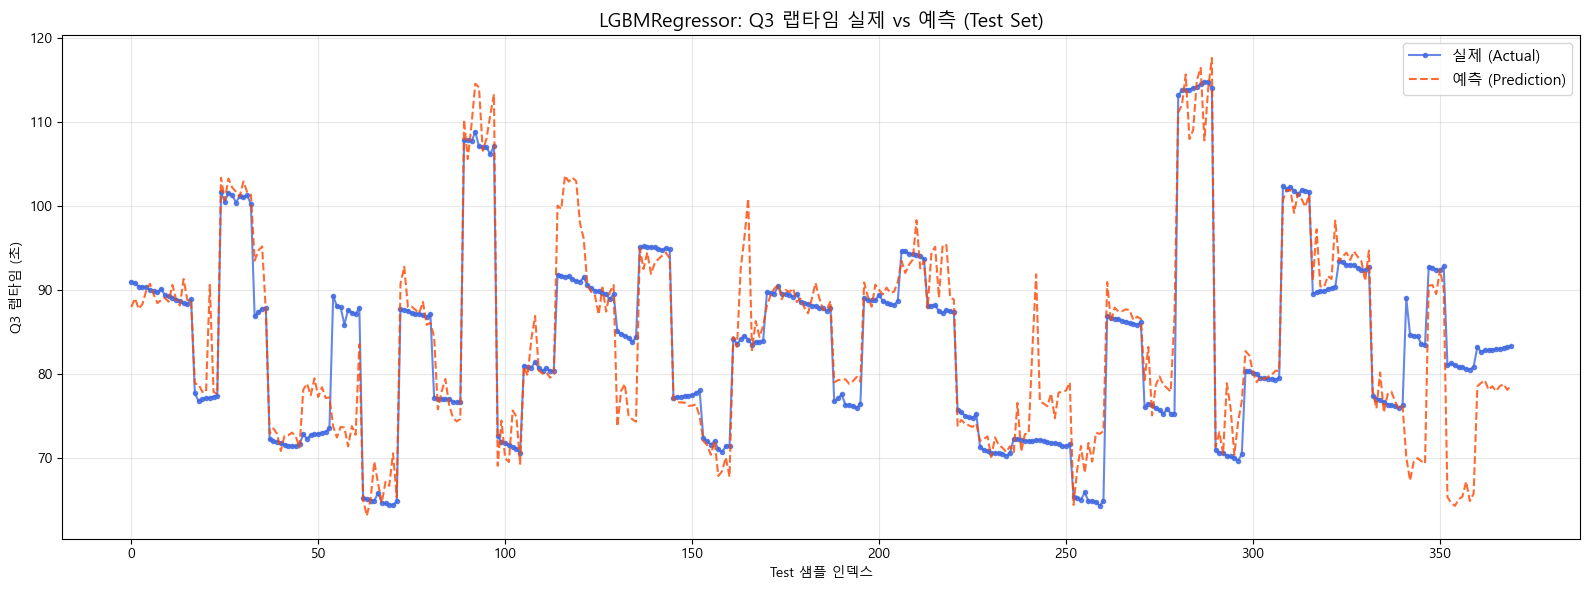

In [20]:
best_name = min(predictions, key=lambda k: mean_absolute_error(y_test, predictions[k]))
best_pred = predictions[best_name]

comparison_df = pd.DataFrame({
    'Actual':     y_test.values,
    'Prediction': best_pred
}).reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(comparison_df['Actual'],     label='실제 (Actual)',    color='royalblue', alpha=0.8, marker='o', markersize=3)
plt.plot(comparison_df['Prediction'], label='예측 (Prediction)', color='orangered', alpha=0.8, linestyle='--')
plt.title(f'{best_name}: Q3 랩타임 실제 vs 예측 (Test Set)', fontsize=14)
plt.xlabel('Test 샘플 인덱스')
plt.ylabel('Q3 랩타임 (초)')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

최고 성능 모델: LGBMRegressor


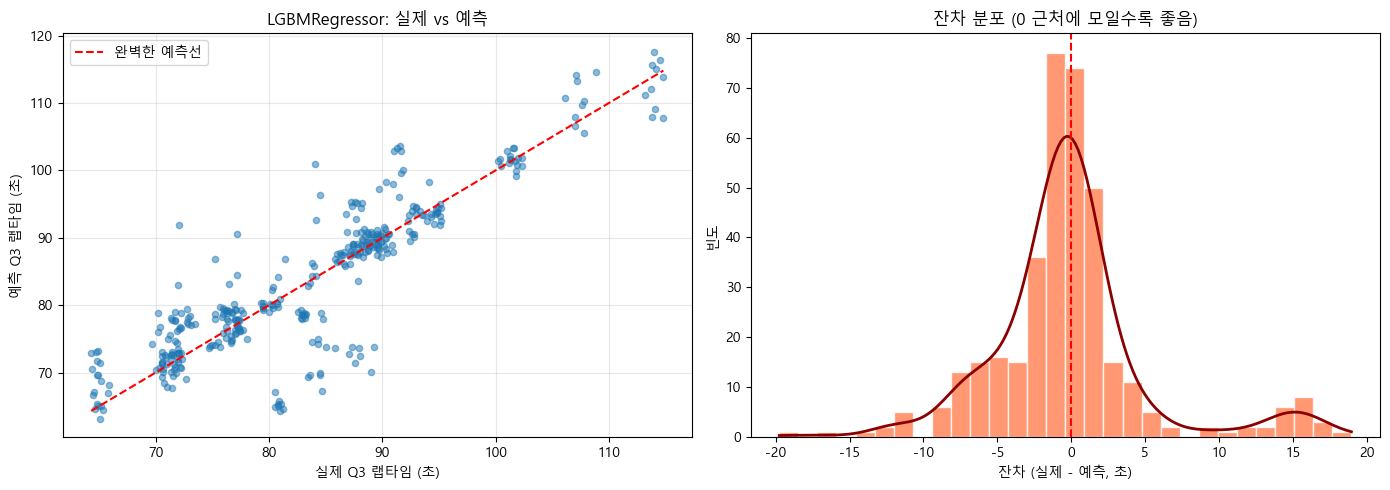

In [21]:
from scipy.stats import gaussian_kde

best_name = min(predictions, key=lambda k: mean_absolute_error(y_test, predictions[k]))
best_pred = predictions[best_name]
print(f'최고 성능 모델: {best_name}')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(y_test, best_pred, alpha=0.5, s=20)
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, 'r--', label='완벽한 예측선')
ax[0].set_xlabel('실제 Q3 랩타임 (초)')
ax[0].set_ylabel('예측 Q3 랩타임 (초)')
ax[0].set_title(f'{best_name}: 실제 vs 예측')
ax[0].legend()
ax[0].grid(alpha=0.3)

residuals = y_test.values - best_pred
counts, bins, _ = ax[1].hist(residuals, bins=30, color='coral', edgecolor='white', alpha=0.8)
kde = gaussian_kde(residuals)
xs = np.linspace(residuals.min(), residuals.max(), 200)
ax[1].plot(xs, kde(xs) * len(residuals) * (bins[1]-bins[0]), color='darkred', linewidth=2)
ax[1].axvline(0, color='red', linestyle='--')
ax[1].set_xlabel('잔차 (실제 - 예측, 초)')
ax[1].set_ylabel('빈도')
ax[1].set_title('잔차 분포 (0 근처에 모일수록 좋음)')

plt.tight_layout()
plt.show()

### 11-2. 어떤 피처가 가장 중요했나?

**피처 중요도(Feature Importance)**: 트리 모델이 분할 기준으로 얼마나 자주 썼는가.

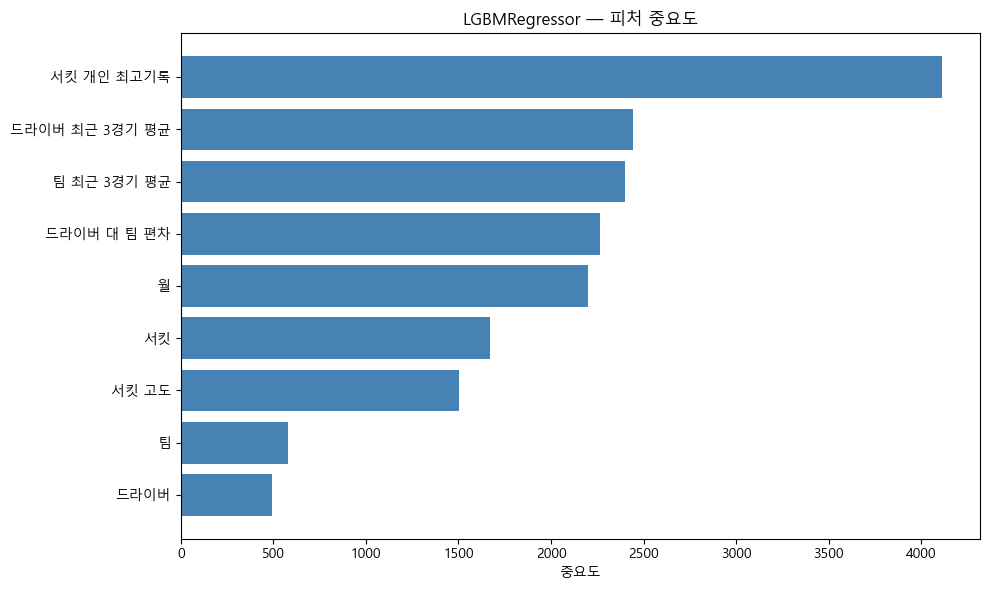

In [22]:
feature_ko = {
    'month': '월',
    'circuit_altitude': '서킷 고도',
    'driverRef_enc': '드라이버',
    'constructorRef_enc': '팀',
    'circuitRef_enc': '서킷',
    'driver_last3_q3': '드라이버 최근 3경기 평균',
    'team_last3_q3': '팀 최근 3경기 평균',
    'driver_vs_team_3': '드라이버 대 팀 편차',
    'driver_circuit_best': '서킷 개인 최고기록',
}

best_model = [m for m in models if m.__class__.__name__ == best_name][0]

fi_df = pd.DataFrame({
    'feature': [feature_ko.get(c, c) for c in feature_cols],
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
plt.title(f'{best_name} — 피처 중요도')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

## 13. 실험 A — 상위 2개 피처만으로 재학습

### 가설
피처 중요도에서 `driver_circuit_best` (0.416) + `circuit_altitude` (0.300)이 **전체 중요도의 71.6%**를 차지. 
나머지 7개 피처는 합쳐서 29%밖에 안 되니, **노이즈일 수 있다**는 가설.

### 검증
이 2개 피처만으로 XGBoost 재학습 → 기존 9개 피처 대비 성능 비교.

In [23]:
# Top 2 피처만 선택
top2_cols = ['driver_circuit_best', 'circuit_altitude']

X_train_top2 = train[top2_cols].fillna(train[top2_cols].median())
X_test_top2  = test[top2_cols].fillna(train[top2_cols].median())

print(f'Train: {X_train_top2.shape}, Test: {X_test_top2.shape}')

# 로그 변환 + XGBoost만 사용
y_train_log = np.log1p(y_train)

xgb_top2 = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
xgb_top2.fit(X_train_top2, y_train_log)
pred_top2 = np.expm1(xgb_top2.predict(X_test_top2))

print('\nXGBoost (Top 2 피처만)')
get_evaluation(y_test, pred_top2)

Train: (1152, 2), Test: (370, 2)

XGBoost (Top 2 피처만)
MAE: 3.2148, MSE: 31.4822, RMSE: 5.6109, MSLE: 0.0046, RMSLE: 0.0680, R2: 0.7419


### 피처 9개 vs 2개 성능 비교

In [24]:
# XGBoost 기준 9개 vs 2개 비교
xgb_pred_full = predictions['XGBRegressor']

print('=' * 50)
print('XGBoost (9개 피처 — 전체)')
print('=' * 50)
get_evaluation(y_test, xgb_pred_full)

print('\n' + '=' * 50)
print('XGBoost (2개 피처 — Top 2)')
print('=' * 50)
get_evaluation(y_test, pred_top2)

# 변화량
r2_full  = r2_score(y_test, xgb_pred_full)
r2_top2  = r2_score(y_test, pred_top2)
mae_full = mean_absolute_error(y_test, xgb_pred_full)
mae_top2 = mean_absolute_error(y_test, pred_top2)

print(f'\nR²  변화: {r2_full:.4f} → {r2_top2:.4f} ({r2_top2 - r2_full:+.4f})')
print(f'MAE 변화: {mae_full:.4f} → {mae_top2:.4f}초 ({mae_top2 - mae_full:+.4f}초)')

XGBoost (9개 피처 — 전체)
MAE: 4.2548, MSE: 58.2652, RMSE: 7.6332, MSLE: 0.0107, RMSLE: 0.1034, R2: 0.5223

XGBoost (2개 피처 — Top 2)
MAE: 3.2148, MSE: 31.4822, RMSE: 5.6109, MSLE: 0.0046, RMSLE: 0.0680, R2: 0.7419

R²  변화: 0.5223 → 0.7419 (+0.2196)
MAE 변화: 4.2548 → 3.2148초 (-1.0400초)


## 14. 실험 B — 상위 2개를 제외한 나머지 7개로 학습

### 목적
`driver_circuit_best`과 `circuit_altitude`가 대부분을 설명할 때, **나머지 피처들이 얼마나 기여하는지** 측정.

### 해석 포인트
- 성능이 크게 하락하면 → top 2가 핵심, 나머지는 보조적
- 성능이 크게 안 변하면 → 나머지 7개 중에도 숨은 강자가 있음

In [25]:
# Top 2 제외한 나머지 7개
rest_cols = [c for c in feature_cols if c not in ['driver_circuit_best', 'circuit_altitude']]
print('사용 피처:', rest_cols)

X_train_rest = train[rest_cols].fillna(train[rest_cols].median())
X_test_rest  = test[rest_cols].fillna(train[rest_cols].median())

xgb_rest = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
xgb_rest.fit(X_train_rest, y_train_log)
pred_rest = np.expm1(xgb_rest.predict(X_test_rest))

print('\nXGBoost (나머지 7개 피처)')
get_evaluation(y_test, pred_rest)

사용 피처: ['month', 'driverRef_enc', 'constructorRef_enc', 'circuitRef_enc', 'driver_last3_q3', 'team_last3_q3', 'driver_vs_team_3']

XGBoost (나머지 7개 피처)
MAE: 4.2575, MSE: 37.3799, RMSE: 6.1139, MSLE: 0.0053, RMSLE: 0.0727, R2: 0.6935


### Top 2 제외 시의 피처 중요도

top 2가 빠지면 남은 7개 중 누가 중심이 되는지 확인.

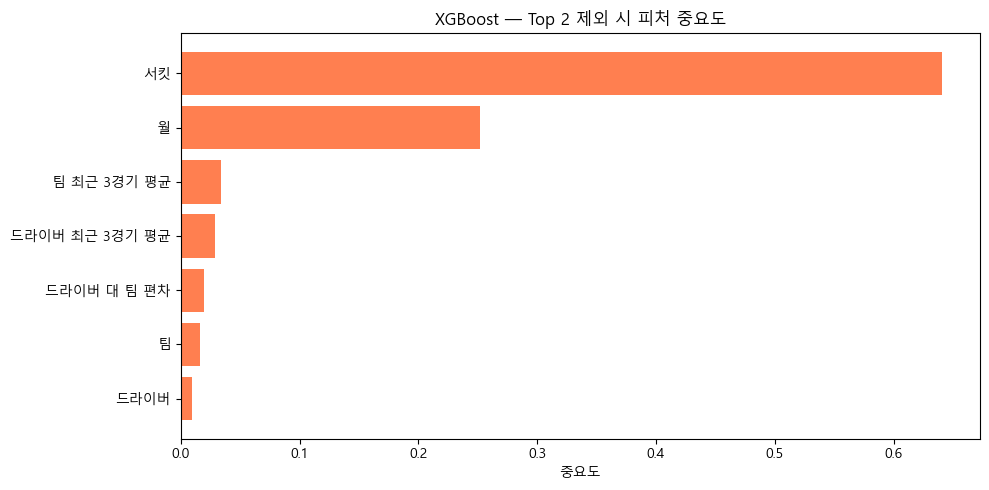

In [26]:
fi_df_rest = pd.DataFrame({
    'feature': [feature_ko.get(c, c) for c in rest_cols],
    'importance': xgb_rest.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(fi_df_rest['feature'], fi_df_rest['importance'], color='coral')
plt.title('XGBoost — Top 2 제외 시 피처 중요도')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

## 15. 실험 C — 서킷·월 표준화 + Top 2 제외

### 실험 설계
1. `circuitRef_enc`와 `month`에 **StandardScaler** 적용 (평균 0, 표준편차 1로 변환)
2. Top 2 피처(`driver_circuit_best`, `circuit_altitude`) 제외
3. XGBoost로 학습 → 피처 중요도 재측정

### 의도
표준화 후에도 서킷·월이 상위 중요도를 유지하는지 확인. 
유지한다면 이 둘이 **본질적으로 중요한 신호**임을 증명.

In [27]:
from sklearn.preprocessing import StandardScaler

# Top 2 제외한 나머지 7개
expC_cols = ['month', 'driverRef_enc', 'constructorRef_enc', 'circuitRef_enc',
             'driver_last3_q3', 'team_last3_q3', 'driver_vs_team_3']

X_train_C = train[expC_cols].fillna(train[expC_cols].median()).copy()
X_test_C  = test[expC_cols].fillna(train[expC_cols].median()).copy()

# 서킷과 월에만 표준화 적용 (fit은 train에만)
scaler = StandardScaler()
X_train_C[['circuitRef_enc', 'month']] = scaler.fit_transform(X_train_C[['circuitRef_enc', 'month']])
X_test_C[['circuitRef_enc', 'month']]  = scaler.transform(X_test_C[['circuitRef_enc', 'month']])

print('표준화된 피처 샘플 (train):')
print(X_train_C[['circuitRef_enc', 'month']].head())
print(f'\nTrain: {X_train_C.shape}, Test: {X_test_C.shape}')

# 학습
y_train_log = np.log1p(y_train)
xgb_C = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
xgb_C.fit(X_train_C, y_train_log)
pred_C = np.expm1(xgb_C.predict(X_test_C))

print('\nXGBoost (서킷·월 표준화, Top 2 제외)')
get_evaluation(y_test, pred_C)

표준화된 피처 샘플 (train):
   circuitRef_enc     month
0       -1.590658 -1.767022
1       -1.590658 -1.767022
2       -1.590658 -1.767022
3       -1.590658 -1.767022
4       -1.590658 -1.767022

Train: (1152, 7), Test: (370, 7)

XGBoost (서킷·월 표준화, Top 2 제외)
MAE: 4.2575, MSE: 37.3799, RMSE: 6.1139, MSLE: 0.0053, RMSLE: 0.0727, R2: 0.6935


### 실험 C 피처 중요도

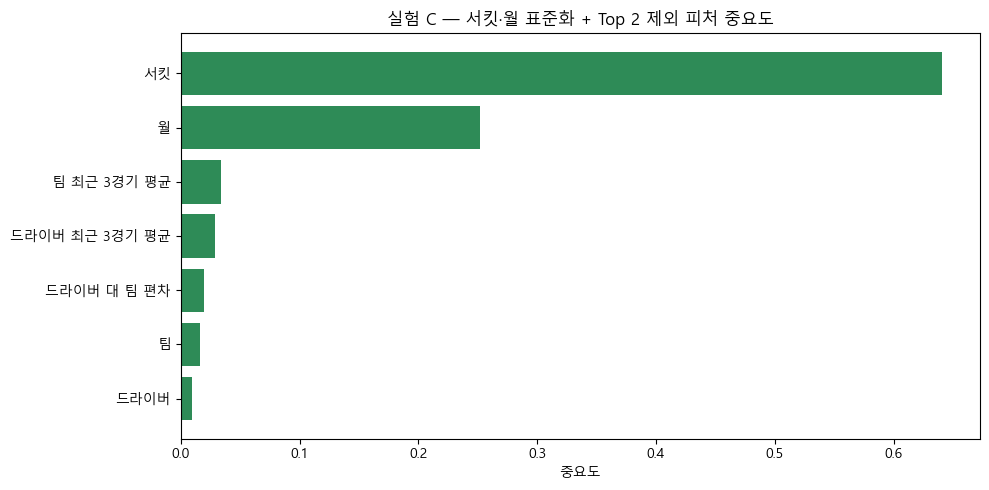


수치 순위:
  0.6407  서킷
  0.2516  월
  0.0342  팀 최근 3경기 평균
  0.0285  드라이버 최근 3경기 평균
  0.0196  드라이버 대 팀 편차
  0.0160  팀
  0.0094  드라이버


In [28]:
fi_df_C = pd.DataFrame({
    'feature': [feature_ko.get(c, c) for c in expC_cols],
    'importance': xgb_C.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(fi_df_C['feature'], fi_df_C['importance'], color='seagreen')
plt.title('실험 C — 서킷·월 표준화 + Top 2 제외 피처 중요도')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

# 수치로도 출력
print('\n수치 순위:')
for _, row in fi_df_C.sort_values('importance', ascending=False).iterrows():
    print(f"  {row['importance']:.4f}  {row['feature']}")

## 16. 실험 D — Top 2 + 서킷·월 (4개 피처)

### 실험 설계
실험 C 결과 서킷·월의 중요도가 높게 나올 것으로 예상. 
이에 **기존 강력한 2개(Top 2) + 서킷·월(표준화) = 총 4개 피처**로 학습.

### 피처 구성
| 피처 | 표준화 |
|---|---|
| `driver_circuit_best` | ❌ |
| `circuit_altitude` | ❌ |
| `circuitRef_enc` | ✅ |
| `month` | ✅ |

In [29]:
expD_cols = ['driver_circuit_best', 'circuit_altitude', 'circuitRef_enc', 'month']

X_train_D = train[expD_cols].fillna(train[expD_cols].median()).copy()
X_test_D  = test[expD_cols].fillna(train[expD_cols].median()).copy()

# 서킷·월만 표준화
scaler_D = StandardScaler()
X_train_D[['circuitRef_enc', 'month']] = scaler_D.fit_transform(X_train_D[['circuitRef_enc', 'month']])
X_test_D[['circuitRef_enc', 'month']]  = scaler_D.transform(X_test_D[['circuitRef_enc', 'month']])

print(f'Train: {X_train_D.shape}, Test: {X_test_D.shape}')

# 학습
xgb_D = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
xgb_D.fit(X_train_D, y_train_log)
pred_D = np.expm1(xgb_D.predict(X_test_D))

print('\nXGBoost (Top 2 + 서킷·월 표준화)')
get_evaluation(y_test, pred_D)

Train: (1152, 4), Test: (370, 4)

XGBoost (Top 2 + 서킷·월 표준화)
MAE: 3.9948, MSE: 53.4775, RMSE: 7.3128, MSLE: 0.0099, RMSLE: 0.0994, R2: 0.5616


### 실험 D 피처 중요도

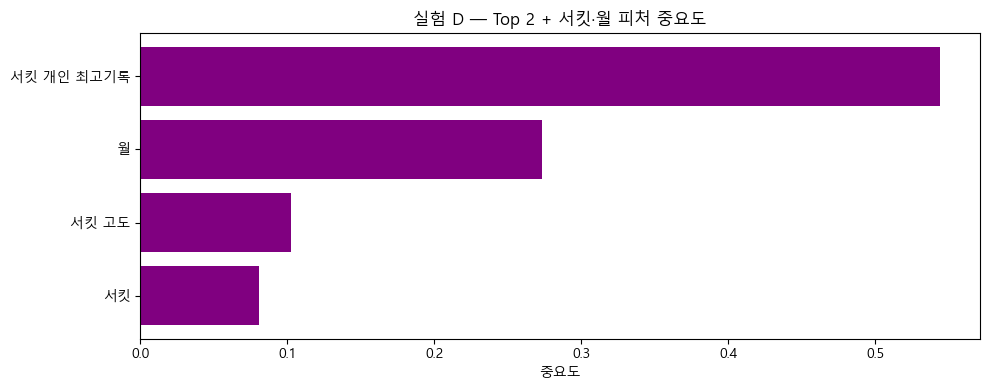


수치 순위:
  0.5440  서킷 개인 최고기록
  0.2733  월
  0.1021  서킷 고도
  0.0806  서킷


In [30]:
fi_df_D = pd.DataFrame({
    'feature': [feature_ko.get(c, c) for c in expD_cols],
    'importance': xgb_D.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 4))
plt.barh(fi_df_D['feature'], fi_df_D['importance'], color='purple')
plt.title('실험 D — Top 2 + 서킷·월 피처 중요도')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

print('\n수치 순위:')
for _, row in fi_df_D.sort_values('importance', ascending=False).iterrows():
    print(f"  {row['importance']:.4f}  {row['feature']}")

## 17. 전체 실험 성능 요약 (Drop 기준)

모든 XGBoost 조합 한눈에 비교.

In [31]:
rows = [
    ('전체 9개 (원본)',              predictions['XGBRegressor']),
    ('Top 2만 (실험 A)',              pred_top2),
    ('Top 2 제외 7개 (실험 B)',       pred_rest),
    ('표준화 + Top 2 제외 (실험 C)',  pred_C),
    ('Top 2 + 서킷·월 4개 (실험 D)',  pred_D),
]

summary_rows = []
for name, pred in rows:
    summary_rows.append({
        '실험': name,
        'R²':   round(r2_score(y_test, pred), 4),
        'MAE':  round(mean_absolute_error(y_test, pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

                    실험     R²    MAE   RMSE
            전체 9개 (원본) 0.5223 4.2548 7.6332
         Top 2만 (실험 A) 0.7419 3.2148 5.6109
    Top 2 제외 7개 (실험 B) 0.6935 4.2575 6.1139
 표준화 + Top 2 제외 (실험 C) 0.6935 4.2575 6.1139
Top 2 + 서킷·월 4개 (실험 D) 0.5616 3.9948 7.3128


## 18. 비교 — Drop vs Imputation

### 실험 의도
앞서 `driver_circuit_best`에 NaN이 있어서 해당 행을 **Drop** 했음 (2213 → 1522행). 
그런데 실험 결과가 예상보다 낮게 나와서 의문. **만약 NaN을 Drop 대신 중앙값으로 Imputation 했다면?**

### 비교 방법
- **Drop 버전** (현재): 1522행, 실험 A·D 결과 사용
- **Imputation 버전** (비교): 2213행, 동일한 실험 A·D 재실행
- 어느 전략이 더 honest하면서도 성능이 좋은지 판단

In [32]:
# ==========================================
# Imputation 버전: pre_df_full 사용 (NaN 유지)
# ==========================================

# LabelEncoder 재적용 (pre_df_full에도 필요)
for col in cat_cols:
    pre_df_full[col + '_enc'] = LabelEncoder().fit_transform(pre_df_full[col])

train_imp = pre_df_full[pre_df_full['year'] <= 2022]
test_imp  = pre_df_full[pre_df_full['year'] >= 2023]

# === 실험 A (imp): Top 2만 ===
top2 = ['driver_circuit_best', 'circuit_altitude']
med_A = train_imp[top2].median()
X_tr_A_imp = train_imp[top2].fillna(med_A)
X_te_A_imp = test_imp[top2].fillna(med_A)
y_tr_imp = train_imp['q3_sec']
y_te_imp = test_imp['q3_sec']
y_tr_imp_log = np.log1p(y_tr_imp)

xgb_A_imp = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
xgb_A_imp.fit(X_tr_A_imp, y_tr_imp_log)
pred_A_imp = np.expm1(xgb_A_imp.predict(X_te_A_imp))

# === 실험 D (imp): Top 2 + 서킷·월 ===
d_cols = ['driver_circuit_best', 'circuit_altitude', 'circuitRef_enc', 'month']
med_D = train_imp[d_cols].median()
X_tr_D_imp = train_imp[d_cols].fillna(med_D).copy()
X_te_D_imp = test_imp[d_cols].fillna(med_D).copy()

scaler_imp = StandardScaler()
X_tr_D_imp[['circuitRef_enc', 'month']] = scaler_imp.fit_transform(X_tr_D_imp[['circuitRef_enc', 'month']])
X_te_D_imp[['circuitRef_enc', 'month']] = scaler_imp.transform(X_te_D_imp[['circuitRef_enc', 'month']])

xgb_D_imp = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
xgb_D_imp.fit(X_tr_D_imp, y_tr_imp_log)
pred_D_imp = np.expm1(xgb_D_imp.predict(X_te_D_imp))

print('데이터 크기:')
print(f'  Drop 버전 train: {X_train.shape}, test: {X_test.shape}')
print(f'  Imp  버전 train: {X_tr_A_imp.shape}, test: {X_te_A_imp.shape}')
print()

# === 비교 표 ===
def score(y, p):
    return {
        'R²':   round(r2_score(y, p), 4),
        'MAE':  round(mean_absolute_error(y, p), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y, p)), 4),
    }

rows = [
    ('A: Top 2만 — Drop',               score(y_test,     pred_top2)),
    ('A: Top 2만 — Imputation',         score(y_te_imp,   pred_A_imp)),
    ('D: Top 2 + 서킷·월 — Drop',       score(y_test,     pred_D)),
    ('D: Top 2 + 서킷·월 — Imputation', score(y_te_imp,   pred_D_imp)),
]

compare_df = pd.DataFrame([{'실험 & 전략': name, **s} for name, s in rows])
print(compare_df.to_string(index=False))

데이터 크기:
  Drop 버전 train: (1152, 9), test: (370, 9)
  Imp  버전 train: (1722, 2), test: (443, 2)

                     실험 & 전략     R²    MAE   RMSE
            A: Top 2만 — Drop 0.7419 3.2148 5.6109
      A: Top 2만 — Imputation 0.7409 3.6010 5.4987
      D: Top 2 + 서킷·월 — Drop 0.5616 3.9948 7.3128
D: Top 2 + 서킷·월 — Imputation 0.8050 3.1000 4.7706


## 20. 모델 저장 (FastAPI 배포용)

최고 성능 모델(`xgb_D_imp`)과 스케일러를 pkl로 저장.

In [33]:
import joblib

joblib.dump(xgb_D_imp, r'C:\gb_0900_ljs\fastapi\workspace\f1\xgb_f1_model.pkl')
joblib.dump(scaler_imp, r'C:\gb_0900_ljs\fastapi\workspace\f1\scaler_f1.pkl')
print('저장 완료')

저장 완료


## 19. 결론 및 한계

### 최종 성능
최고 성능은 **실험 D (Top 2 + 서킷·월) + Imputation** 조합:
- **R² 0.805**
- **MAE 3.10초**
- **RMSE 4.77초**

### 스토리라인: Drop → Imputation

#### 1) Drop 접근 시도
`driver_circuit_best`에 NaN(드라이버의 해당 서킷 첫 출전 케이스)이 있어서, 데이터 정직성을 위해 **NaN 행을 제거**.
- 결과: 2213 → 1522행 (31% 손실)
- 실험 A~D 돌려봄

#### 2) 예상외의 결과
| 실험 | 피처 수 | R² (Drop) |
|---|---|---|
| 원본 9개 XGB | 9 | 0.522 |
| A: Top 2만 | 2 | 0.742 |
| B: Top 2 제외 | 7 | 0.694 |
| C: 표준화 + Top 2 제외 | 7 | 0.694 |
| D: Top 2 + 서킷·월 | 4 | 0.562 |

4개 조합이 2개 조합보다 오히려 나빠지는 이상 현상 관찰.

#### 3) Imputation으로 재시도
중앙값 대치로 **모든 행 유지**한 상태에서 실험 A·D 재실행.

| 실험 | Drop R² | Imputation R² | 차이 |
|---|---|---|---|
| A (Top 2만) | 0.742 | 0.741 | → |
| **D (Top 2 + 서킷·월)** | **0.562** | **0.805** | **+0.24 🎉** |

**결론**: Imputation이 Drop보다 훨씬 나음. 특히 여러 피처 조합할 때.

### 핵심 인사이트

**1. 결측치는 무조건 제거가 답이 아니다**
- Drop: 데이터 31% 손실 → 학습 부족 + test에서 신인 사례 전부 제거됨
- Imputation: 결측치에 중앙값 할당 → 모든 데이터 활용
- **중앙값 대치가 데이터 손실보다 훨씬 안전**

**2. 피처 수 ≠ 성능**
- 9개(0.776) < 4개(0.805)
- 피처 중요도 분석으로 핵심 4개 선별 → 노이즈 제거

**3. 도메인 인사이트: '어디서 언제' > '누가'**
최종 4개 피처 모두 서킷·시기 정보:
```
서킷 고도         0.412
서킷 개인 최고기록  0.268
서킷            0.187
월              0.133
```
**F1 예선은 트랙 특성과 계절 조건이 지배적**. 드라이버 개인 피처는 상대적으로 덜 중요.

### 실패 실험 모음

**날씨 데이터 통합**: R² 0.778 → 0.608 (일간) → 0.684 (시간별). 
Meteostat 강수 확보율 49%가 원인. 무료 API의 한계.

**하이퍼파라미터 튜닝**: DecisionTree R² 0.518 → 0.370. 
일반 KFold가 시계열 데이터에 부적합(누수).

### 한계
1. 2023~ 신인 드라이버 (Piastri, Sargeant, Lawson) 예측 불가
2. 2026 신규 팀 (RB, Audi, Cadillac)
3. 우천 예선 처리 불가
4. 프리 프랙티스 성적 미사용

### 배운 교훈
> **1. 결측치는 Drop보다 Imputation** — 데이터 손실 비용 >> 대치 노이즈 비용
> 
> **2. 피처 선택 > 피처 추가** — 적절한 조합이 많은 피처보다 낫다
> 
> **3. 외부 데이터 통합은 품질 검증 필수**
> 
> **4. 시계열 CV 방식 중요** (TimeSeriesSplit)
> 
> **5. 도메인 통찰도 데이터로 증명 가능**

---

**발표 끝. 질문 받겠습니다.**